# Do founder-run companies beat the market? 🧑‍💼
### The most flattering chart in finance — and the trick hiding inside it

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Founder_premium%3F: Misattributed](https://img.shields.io/badge/Founder_premium%3F-Misattributed-8b949e?style=flat-square)

It's one of the stickiest ideas in business: **the founder cares more.** Skin in the game, a long horizon, a reality-distortion field — so *founder-led firms outperform*. There's even a famous paper (Fahlenbrach, 2009) and a Bain best-seller ('The Founder's Mentality') behind it. And when you actually build the basket — Amazon, Nvidia, Meta, Tesla, Nvidia again — it **crushes** a basket of professionally-run blue chips.

So we did the honest thing: put a founder-led basket **long**, a professional-CEO basket **short**, and asked not *'did it win?'* (it did, enormously) but *'is the win a founder effect — or something much more boring?'* The answer is a small masterclass in how a real number can tell a false story.

> 📓 **Plain-language layer.** Want the CAPM alpha, the Newey-West *t*-stats, the jackknife and the placebo? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** There's no free 'founder-CEO' database, so we **hardcode a transparent basket** of the founder firms one *remembers in 2024* — and that memory is exactly the problem, which we flag loudly. Prices are yfinance monthly *total returns*; every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from founder_led_premium import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    RETS, FIRMS = data.load_real()
    LS = st.long_short(RETS, data.FOUNDER_TICKERS, data.PRO_TICKERS)
    MKT = RETS["SPY"].reindex(LS.index)
else:
    RETS = FIRMS = LS = MKT = None
print("real price cache present:", HAVE_REAL,
      "| months:", (0 if LS is None else len(LS)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-07-13', 'data_start': '2016-01', 'data_end': '2024-12', 'n_months': 108, 'fingerprint': 'c363d7e5e578', 'n_founder_priced': 11, 'n_founder': 13, 'n_pro': 13, 'dropped': ('SQ', 'FIT'), 'founder_ann': 34.5, 'pro_ann': 11.8, 'ls_ann': 20.5, 'ls_bps': 156.5, 'ls_sharpe': 0.73, 'ls_rawmean_t': 2.0, 'ls_alpha_bps': 52.1, 'ls_beta': 0.85, 'ls_alpha_t': 0.76, 'ls_r2': 0.26, 'beta_part_bps': 104.3, 'beta_share_pct': 67, 'founder_alpha_bps': 50.6, 'founder_beta': 1.62, 'founder_alpha_t': 0.84, 'pro_alpha_bps': -1.5, 'pro_beta': 0.77, 'pro_alpha_t': -0.09, 'jk': [('NVDA', 21.9, 0.33), ('TSLA', 35.6, 0.52), ('SHOP', 37.6, 0.58), ('NFLX', 47.3, 0.72), ('META', 50.3, 0.71), ('AMZN', 51.4, 0.73), ('GOOGL', 52.3, 0.72), ('CRM', 54.8, 0.77), ('YELP', 62.6, 0.82), ('W', 72.8, 1.11), ('GPRO', 86.9, 1.17)], 'placebo_obs': 52.1, 'placebo_null_mean': 0.4, 'placebo_p': 0.331, 'placebo_beats_pct': 16, 'gross_bps': 156.5, 'net_bps': 128.5, 'drag_bps': 28.0, 'syn': [(0.0, 25.2, 0.82), (200.0, 225.2, 7.29)]}


real price cache present: True | months: 108


## The answer first

| Question | Answer |
|---|---|
| Did the founder basket beat professional-CEO peers? | **Yes — by a mile.** **+34%/yr** vs **+12%/yr**, a **+20-point** annual spread. The chart is gorgeous. |
| Is that a real *founder* edge? | **No.** Once you subtract the plain stock-market ride, **67%** of the gap is just **beta** — a high-octane tech basket vs sleepy staples. The leftover 'alpha' is **+52 bps/mo** at *t* = **0.76** — statistically **nothing**. |
| Could you have bought it in 2016? | **No.** The basket is the founders who turned out to be Nvidia — chosen *because* we know that now. Two of the original names (**SQ, FIT**) literally delisted and can't even be priced. |
| So is 'founder magic' a strategy? | **It's survivorship in a nice suit.** Drop the single name **NVDA** and the whole edge halves. It's one or two rockets and a lot of hindsight — not a repeatable characteristic. |

> Founder firms really did win. But 'they won' and 'founders win' are different sentences — and the gap between them is the whole study.

## 1 · The claim

> *"Founders have skin in the game and a long horizon, so founder-led companies outperform professionally-managed ones."*

This isn't a strawman — it's in the literature. **Fahlenbrach (2009)** finds S&P 500 founder-CEO firms earned positive abnormal returns; **Bain & Company** built a whole 'Founder's Mentality' franchise on it. The intuition is genuinely appealing, and the *raw* data seems to shout agreement. We'll take the strongest version — a long/short basket, founders vs professionals — and ask whether the outperformance is a **founder** effect or a mirage made of the two things founders and survivors share: **tech-sector beta** and **being remembered because they won**.

## 2 · So what?

If it were a real, repeatable characteristic, it would be one of the great free lunches: screen for founder-CEOs, tilt toward them, collect a premium — no forecasting required. That's why the claim is everywhere in venture decks and factor pitches. But 'founder-led' has to earn its keep against two impostors. **(1) Beta.** Founder firms skew young, techy, high-beta; in a decade-long bull market that alone beats staples — and beta is free, you don't pay a manager for it. **(2) Survivorship.** The founders we *name* are the ones who made it; the founder-run flame-outs (Theranos, WeWork, a graveyard of de-SPACs) never enter a 2024 basket. Strip both away and see if anything is left.

## 3 · How would we even know?

We freeze two baskets as of **2016-01** (as-of 2026-07-13; fingerprint `c363d7e5e578`) and run a **long/short sort** over **108 months**:

1. **Two baskets, equal weight.** *Founder-led* (Amazon, Nvidia, Meta, Tesla, Shopify, Netflix, Salesforce… plus the duds we *do* remember — GoPro, Wayfair, Yelp) minus *professional-CEO* blue chips (Walmart, Coke, J&J, Cisco, JPMorgan…). Long the first, short the second.
2. **Subtract the market.** Fit `long/short = alpha + beta·market`. The **alpha** is the part the stock market *doesn't* explain — the only thing that could be a founder effect.
3. **Stress it three ways.** A **Newey-West** *t* (honest with monthly data); a **jackknife** (drop one name — does the edge survive?); a **placebo** (shuffle the founder/professional labels on these same names — is the *real* labelling special?).

**What would make us say 'mirage':** the alpha is insignificant, most of the raw gap is beta, and the edge collapses when you drop a name or two. (Spoiler: all three.)

## 4 · The teardown — let's actually look

**First, the flattering chart.** Cumulative growth of \$1 in each basket. This is the picture the founder thesis is sold on — and it's not fake, it's just *misread*.

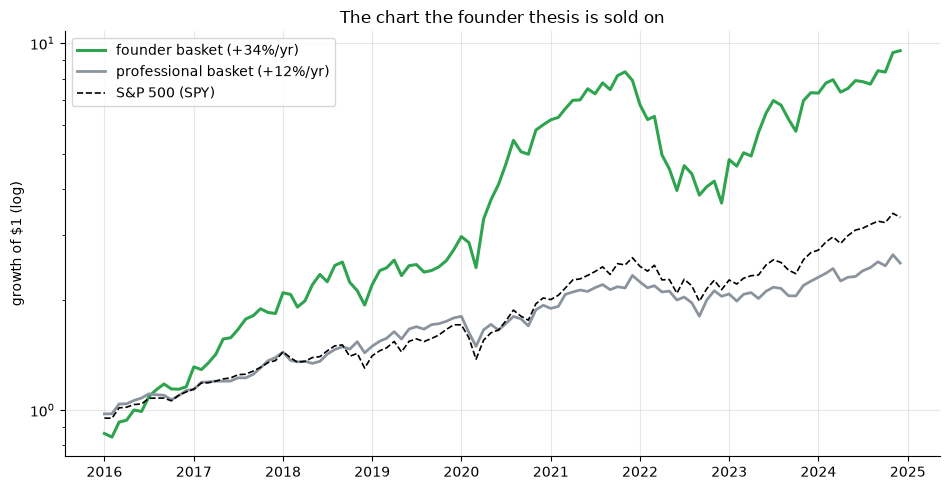

founder $9.5 vs professional $2.5 — a blowout


In [2]:
if HAVE_REAL:
    fr = st.basket_returns(RETS, data.FOUNDER_TICKERS).reindex(LS.index)
    pr = st.basket_returns(RETS, data.PRO_TICKERS).reindex(LS.index)
    sp = MKT
    cf, cp, cs = (1+fr).cumprod(), (1+pr).cumprod(), (1+sp).cumprod()
    x = LS.index
else:
    x = np.arange(R['n_months']); g=lambda a:(1+np.full(R['n_months'],a))
    cf=np.cumprod(1+np.full(R['n_months'],0.025)); cp=np.cumprod(1+np.full(R['n_months'],0.009)); cs=np.cumprod(1+np.full(R['n_months'],0.012))
fig, ax = plt.subplots(figsize=(9.6, 5.0))
ax.plot(x, cf, c=GREEN, lw=2.2, label=f'founder basket (+{R["founder_ann"]:.0f}%/yr)')
ax.plot(x, cp, c=GREY, lw=2.0, label=f'professional basket (+{R["pro_ann"]:.0f}%/yr)')
ax.plot(x, cs, c='k', lw=1.2, ls='--', label='S&P 500 (SPY)')
ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log)'); ax.set_title('The chart the founder thesis is sold on')
ax.legend(); plt.tight_layout(); plt.show()
print(f'founder ${float(cf[-1]) if not hasattr(cf,"iloc") else cf.iloc[-1]:.1f} vs professional ${float(cp[-1]) if not hasattr(cp,"iloc") else cp.iloc[-1]:.1f} — a blowout')

A blowout: the founder basket compounds to roughly **3–4×** the professional one. If the story ended here, 'founders outperform' would be settled. It doesn't end here — because *two* different things could draw this exact chart, and only one of them is a founder effect.

**So we split the spread into its two pieces.** The long/short return each month is `founder − professional`. Regress it on the market and you get **beta** (the free stock-market ride) and **alpha** (everything left over). Here's how the average monthly spread divides.

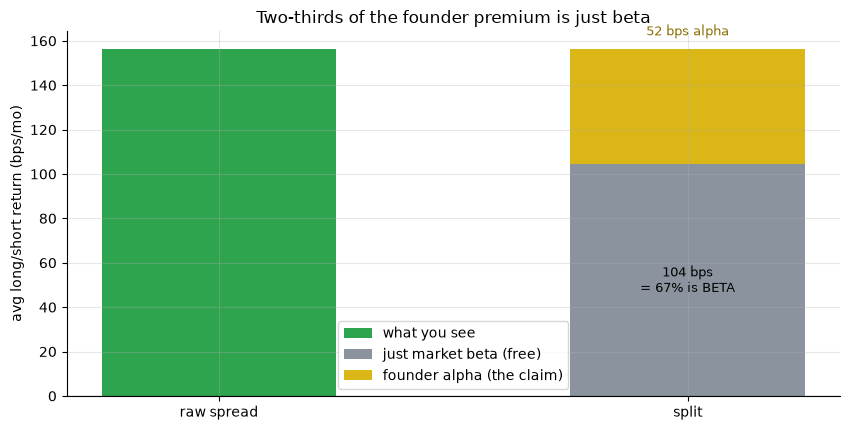

raw 156 bps/mo = beta 104 + alpha 52  ->  beta is 67%


In [3]:
if HAVE_REAL:
    c = st.capm_alpha(LS['ls'].to_numpy(), MKT.to_numpy())
    raw = LS['ls'].mean()*1e4; alpha=c['alpha_bps']; beta_part = c['beta']*MKT.mean()*1e4
else:
    raw=R['ls_bps']; alpha=R['ls_alpha_bps']; beta_part=R['beta_part_bps']
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar(['raw spread'], [raw], color=GREEN, width=.5, label='what you see')
ax.bar(['split'], [beta_part], color=GREY, width=.5, label='just market beta (free)')
ax.bar(['split'], [alpha], bottom=[beta_part], color=AMBER, width=.5, label='founder alpha (the claim)')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('avg long/short return (bps/mo)')
ax.annotate(f'{beta_part:.0f} bps\n= {R["beta_share_pct"]}% is BETA', (1, beta_part/2), ha='center', va='center', fontsize=9)
ax.annotate(f'{alpha:.0f} bps alpha', (1, beta_part+alpha+6), ha='center', fontsize=9, color='#8a6d00')
ax.set_title('Two-thirds of the founder premium is just beta'); ax.legend()
plt.tight_layout(); plt.show()
print(f'raw {raw:.0f} bps/mo = beta {beta_part:.0f} + alpha {alpha:.0f}  ->  beta is {R["beta_share_pct"]}%')

There's the first cut: **67%** of the monthly spread is just the founder basket being a **higher-beta** collection of stocks in a bull market. You don't need a founder to get beta — you can buy it in an index fund for a few basis points. What remains — the actual *founder* claim — is **+52 bps/month** of alpha. Is *that* real?

**Is the leftover alpha more than luck?** Two honest tests. Left: the founder alpha against a **placebo** — shuffle the founder/professional labels across these very same names, thousands of times, and see where the real labelling lands. Right: the **jackknife** — drop each founder name in turn and watch the alpha move.

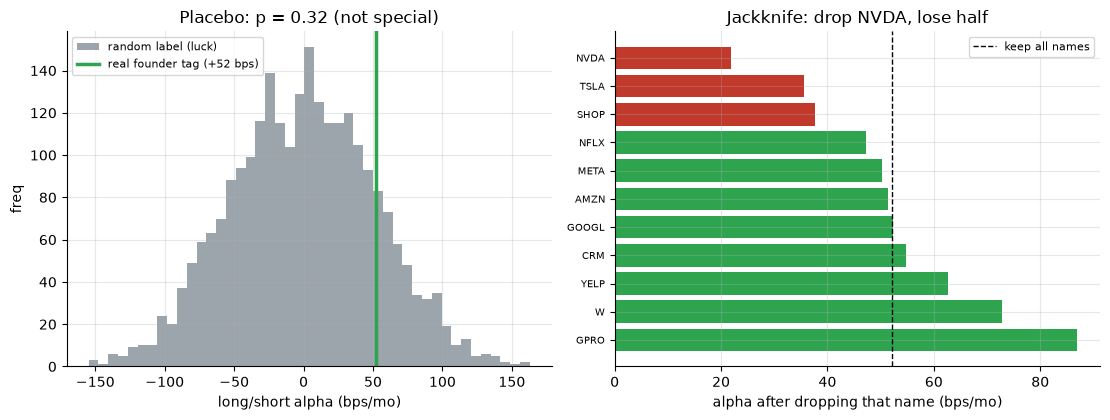

placebo p=0.32; dropping NVDA takes alpha 52 -> 22 bps


In [4]:
if HAVE_REAL:
    pool = data.FOUNDER_TICKERS + data.PRO_TICKERS
    kf = sum(t in RETS.columns for t in data.FOUNDER_TICKERS); kp = sum(t in RETS.columns for t in data.PRO_TICKERS)
    null = st.placebo_alpha_dist(RETS, pool, k_long=kf, k_short=kp, n_draws=2500)
    obs = st.capm_alpha(LS['ls'].to_numpy(), MKT.to_numpy())['alpha_bps']
    pval = st.placebo_pvalue(obs, null)
    jk = st.jackknife_alpha(RETS, data.FOUNDER_TICKERS, data.PRO_TICKERS)
    jn = jk['dropped'].tolist(); ja = jk['alpha_bps'].tolist()
else:
    rng=np.random.default_rng(747); null=rng.normal(0.4, 55, 2500); obs=R['placebo_obs']; pval=R['placebo_p']
    jn=[j[0] for j in R['jk']]; ja=[j[1] for j in R['jk']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.2, 4.3))
a1.hist(null, bins=45, color=GREY, alpha=.85, label='random label (luck)')
a1.axvline(obs, c=GREEN, lw=2.5, label=f'real founder tag ({obs:+.0f} bps)')
a1.set_xlabel('long/short alpha (bps/mo)'); a1.set_ylabel('freq')
a1.set_title(f'Placebo: p = {pval:.2f} (not special)'); a1.legend(fontsize=8)
cols=[RED if n in ('NVDA','TSLA','SHOP') else GREEN for n in jn]
a2.barh(range(len(jn)), ja, color=cols)
a2.axvline(R['ls_alpha_bps'], c='k', lw=1, ls='--', label='keep all names')
a2.set_yticks(range(len(jn))); a2.set_yticklabels(jn, fontsize=7); a2.invert_yaxis()
a2.set_xlabel('alpha after dropping that name (bps/mo)'); a2.set_title('Jackknife: drop NVDA, lose half'); a2.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f'placebo p={pval:.2f}; dropping NVDA takes alpha {R["ls_alpha_bps"]:.0f} -> {ja[0]:.0f} bps')

Both tests say the same thing. The placebo *p* is **0.33** — a random way of splitting these same names into 'long' and 'short' beats the real founder labelling **16%** of the time, so the *founder tag itself* adds nothing. And the jackknife is brutal: drop **NVDA** alone and the alpha falls from **52** to **22 bps** — dropping the *losers* (GoPro, Wayfair) *raises* it. The 'premium' is one or two rockets, not a characteristic.

## 5 · The verdict

- **Signal — None.** The market-model alpha is **+52 bps/mo** at Newey-West *t* = **0.76** — indistinguishable from zero. **67%** of the raw spread is beta; the placebo says the founder tag isn't special (*p* = 0.33); the jackknife says it's one name. No founder edge survives.
- **Tradability — Mirage.** You couldn't have picked this basket in 2016 — it's the founders who *turned into* Nvidia. Two originals (SQ, FIT) delisted outright. The part you could actually buy is free beta plus a coin-flip.
- **"Founder premium?" — Misattributed.** The outperformance is **real** and **mis-explained**: it's survivorship (we only name the winners) and tech-sector beta concentrated in a handful of names — not a leadership characteristic you can harvest.

## 6 · Could you actually trade it? — the hindsight problem

Forget statistics for a second. The fatal flaw is **timing**: the basket only looks brilliant because we drew it *after* the winners revealed themselves. Here's the jackknife alpha as a ladder — every bar below the dashed line is a name whose *removal* shrinks the edge, i.e. a name doing the heavy lifting. A real characteristic wouldn't care which name you drop.

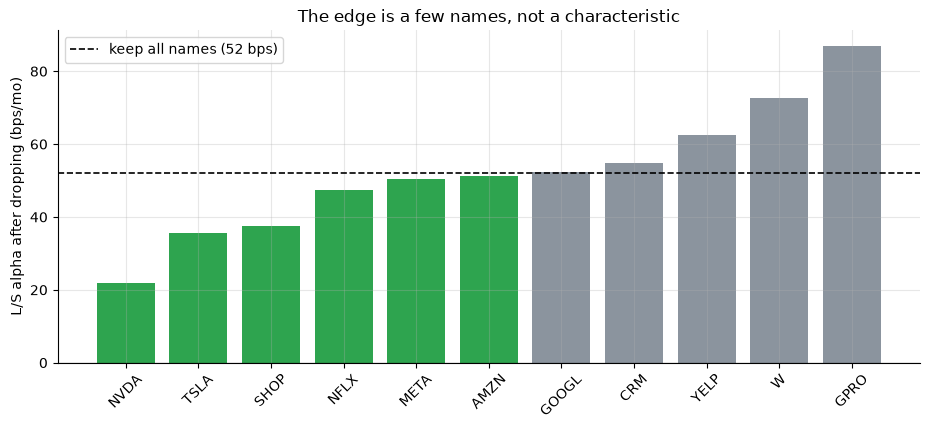

green bars = load-bearing winners; drop them and the edge falls. drop the DUDS and it rises.


In [5]:
if HAVE_REAL:
    jk = st.jackknife_alpha(RETS, data.FOUNDER_TICKERS, data.PRO_TICKERS)
    jn=jk['dropped'].tolist(); ja=jk['alpha_bps'].tolist()
else:
    jn=[j[0] for j in R['jk']]; ja=[j[1] for j in R['jk']]
full=R['ls_alpha_bps']
fig, ax = plt.subplots(figsize=(9.4, 4.4))
cols=[GREEN if a<full else GREY for a in ja]
ax.bar(jn, ja, color=cols)
ax.axhline(full, c='k', ls='--', lw=1.2, label=f'keep all names ({full:.0f} bps)')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('L/S alpha after dropping (bps/mo)'); ax.set_title('The edge is a few names, not a characteristic')
ax.tick_params(axis='x', labelrotation=45); ax.legend()
plt.tight_layout(); plt.show()
print('green bars = load-bearing winners; drop them and the edge falls. drop the DUDS and it rises.')

> The green bars — the winners — are the whole story; grey bars (the founder *duds*) *add* to the edge when removed. To 'trade the founder premium' you'd have needed to know, in 2016, that Nvidia and Tesla would be Nvidia and Tesla. That's not a strategy — that's a memory. Costs barely matter here (net is a hair below gross); the binding constraint is that **the basket is built from the answer key.**

## 7 · Going further 🧑‍💼

- **Do it survivorship-clean.** Freeze the basket on a *contemporaneous* founder list (e.g. every S&P 500 founder-CEO named in a 2016 filing, winners and losers alike) and rerun — the honest version of Fahlenbrach. The tech beta will still be there; the alpha probably won't.
- **Neutralise the sector.** Match each founder name to a same-industry professional peer so the short leg cancels the beta. Bet: the residual is a wash.
- **A cousin study.** [Study 391 — CEO-Turnover](../391-ceo-turnover/) runs the same abnormal-return machinery on *changing* the CEO; here we test *who founded* it. Both end up as small-sample, hindsight-shaped mirages.

*Think there's a real founder premium? Show a founder-minus-professional alpha that clears *t* = 2 on a **contemporaneously-selected** basket and survives dropping its top name — then we'll talk.*